# Generate samples

In [1]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
from copy import deepcopy
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import BurstFormerDataset
from src.model.net import  BurstFormer
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)
add_feature_bin = False
eid = "E118"
fold = 0
# remove_marks = "H3K36me3"
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []


seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]


d_head = config["d_head"]
targets = ['mean_label']
npy_dir = "extra/datasets/processed/v1"

if remove_marks:
    checkpoints = f"checkpoints/{eid}.remove_{remove_marks}.{fold}.mean_para.model.pt"
elif not add_feature_bin:
    checkpoints = f"checkpoints/{eid}.{fold}.No_feature_bin.mean_para.model.pt"
else:
    checkpoints = f"checkpoints/{eid}.{fold}.mean_para.model.pt"
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"


binsizes = [500]


#
# Setup end.
#

seed_everything(seed)
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.

# Split genes into two sets (train/val).
genes = set(meta.gene_id.unique())
n_genes = len(genes)
print("Target genes:", len(genes))
print(f"n_feats_p:{n_feats_p}")

splits = {
    1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
    2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
    3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
    4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
}

chromosome_splits = {}
for key, chroms in splits.items():
    for chrom in chroms:
        chromosome_splits[chrom] = key

qs = [
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
]

train_genes = (
    qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
)
val_genes = qs[(fold + 3) % 4]



print(len(train_genes), len(val_genes))

val_dataset = BurstFormerDataset(
    meta_path,
    npy_dir,
    val_genes,
    i_max,
    binsizes,
    w_prom,
    w_max,
    config = config,
    with_gene_id=True
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=config['num_works'])

model = BurstFormer(
    n_feats_p,
    
    d_emb,
    d_head,
    
    embed_kws=embed_kws,
    binsizes=binsizes,
    seed=42,
    targets=targets,
    
).to(DEVICE)

ckpt = torch.load(checkpoints,map_location=DEVICE)
model.load_state_dict(ckpt["net"])
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target genes: 13854
n_feats_p:7
10494 3360


In [2]:
def evaluation(out:'torch.Tensor', label:torch.Tensor):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return label, pred, acc, auc, ap

In [3]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


# MEAN pred score marks strength

In [11]:
from src.data.utils import bin_and_padding
for _eid in ['E118','E116','E003']:
    data = pd.read_csv(f'extra/datasets/results/{_eid}_predictions_mean_para.csv')
    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{_eid}.csv"
    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')
    high_gene_ids = list(df[df['mean_label_label']==1][['gene_id','strand']].values)

    high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
    high_marks = np.mean(high_marks, axis=0)
    with open(f"extra/datasets/results/{_eid}_mean_para_highmarks.npy", 'wb') as f:
        np.save(f,high_marks)

    low_gene_ids = list(df[df['mean_label_label']==0][['gene_id','strand']].values)
    low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
    low_marks = np.mean(low_marks, axis=0)
    with open(f"extra/datasets/results/{_eid}_mean_para_lowmarks.npy", 'wb') as f:
        np.save(f,low_marks)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


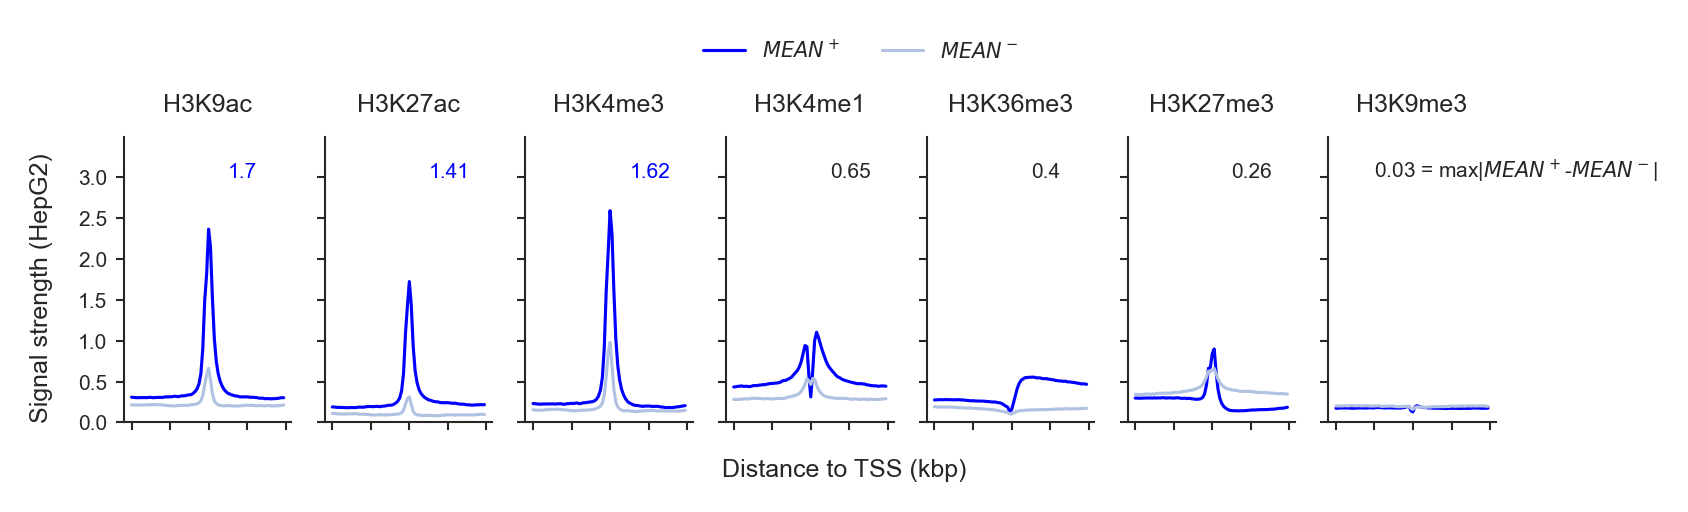

In [9]:
eid = 'E118'
high_marks = np.load(f"extra/datasets/results/{eid}_mean_highmarks.npy")
low_marks = np.load(f"extra/datasets/results/{eid}_mean_lowmarks.npy")
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(14/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='blue',  ax=ax[idx % 7])
    sns.lineplot(low_marks[_idx], color=(177/255,193/255,225/255),  ax=ax[idx % 7])
    # ax[idx % 7].text(0,1.7,f"max|$BS^+-BF^-$|={round(max(abs(high_marks[_idx]-low_marks[_idx])),2)}",fontdict={"size":5}) 
    if idx < 3:
        ax[idx % 7].text(50,3.0,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5}, color='blue')
    elif idx ==6:
        ax[idx % 7].text(20,3.0,f"{round(max(abs(high_marks[_idx]-low_marks[_idx])),2)} = max|$MEAN^+$-$MEAN^-$|",fontdict={"size":5})
    else:
        ax[idx % 7].text(50,3.0,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5})
    # Set the y-axis ticks
    ax[idx % 7].set_yticks([i * 0.1 for i in range(0, 31, 5)])
    ax[idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
    if idx == 0:
        ax[idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False)
    else:
        ax[idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False,labelleft=False)
    # Set the title for each subplot
    ax[idx % 7].set_title(mark, fontsize=6,fontweight='regular')
    ax[idx % 7].set_ylim(ymax=3.5)
    # Set the xlabel for each subplot

lines = ax[6].get_lines()

handles = [lines[0], lines[1]]
labels = ["$MEAN^+$", "$MEAN^-$"]

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.51, 1.15) , title_fontsize=6,fontsize=5,ncol=4,edgecolor='none')

fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
fig.supylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)
fig.align_ylabels()
# Adjust layout to ensure everything fits



plt.savefig(f'extra/datasets/figures/Figure5A_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


# Model Performance

In [10]:
targets=['mean_label']
with open('extra/datasets/results/mean_para_indicators.csv','w') as w:
    line = ['eid','fold','auc','target']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:            
        for fold in [0,1,2,3]:
            checkpoints = f"checkpoints/{eid}.{fold}.No_feature_bin.mean_para.model.pt"
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            for target in targets:
                auc = ckpt[f"{target}_val_auc"]
                line = [eid,str(fold),str(auc),target]
                w.write(','.join(line) + '\n')

data = pd.read_csv('extra/datasets/results/mean_para_indicators.csv')
data

,eid,fold,auc,target
0,E116,0,98.580768,mean_label
1,E116,1,98.788922,mean_label
2,E116,2,98.966780,mean_label
3,E116,3,98.993458,mean_label
4,E118,0,95.286619,mean_label
5,E118,1,96.161930,mean_label
6,E118,2,96.086167,mean_label
7,E118,3,97.137449,mean_label
8,E003,0,96.794295,mean_label
9,E003,1,96.925120,mean_label


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_83969/2250877654.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


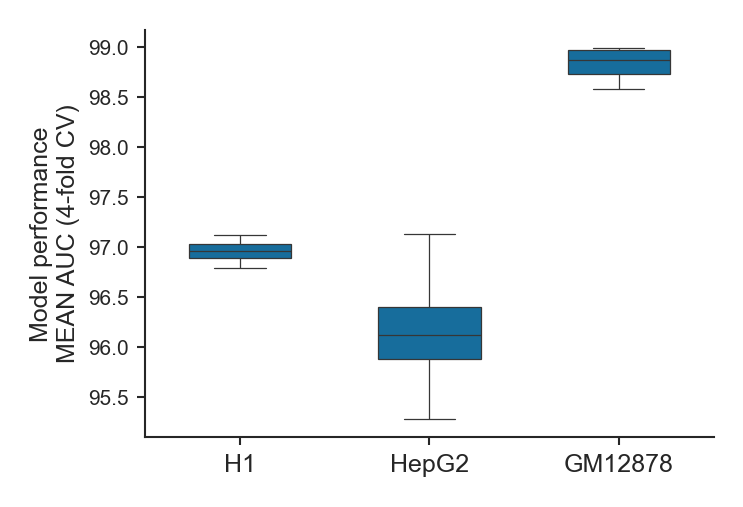

In [11]:
data = pd.read_csv('extra/datasets/results/mean_para_indicators.csv')

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')

ax = sns.boxplot(data=data,x='eid',y='auc',
                 fliersize=0, 
                 linewidth=0.3,
                 ax=ax,order=order,
                 gap=0.1,width=0.6,)

# Show the plot
ax.set_ylabel("Model performance\nMEAN AUC (4-fold CV)",fontsize=6)
ax.set_xlabel("")
ax.tick_params(axis='x', labelsize=6,width=0.5)
ax.tick_params(axis='y', labelsize=5,width=0.5)
# ax.set_ylim(bottom=93)
# handles, labels = ax.get_legend_handles_labels()
# labels = ["BF","BS"]
# ax.legend().remove()

ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 0.95), fontsize=5,ncol=1,edgecolor='none')
# plt.savefig('extra/datasets/figures/Figure2A_MEAN.eps', format='eps', bbox_inches='tight')

# plt.tight_layout()  # Adjust layout to ensure nothing is cut off
plt.show()

## AUC curve

In [13]:
data = pd.read_csv(f'extra/datasets/results/{eid}_predictions_mean_para.csv')
data

,gene_id,mean_label_label,mean_label_score,mean_label_pred,fold
0,ENSG00000122705,1,0.995865,1,0
1,ENSG00000184867,1,0.958913,1,0
2,ENSG00000141052,0,0.080642,0,0
3,ENSG00000180071,0,0.201534,0,0
4,ENSG00000132530,0,0.021331,0,0
...,...,...,...,...,...
14490,ENSG00000153234,0,0.087987,0,3
14491,ENSG00000177150,1,0.797512,1,3
14492,ENSG00000233701,0,0.008562,0,3
14493,ENSG00000163535,1,0.973283,1,3


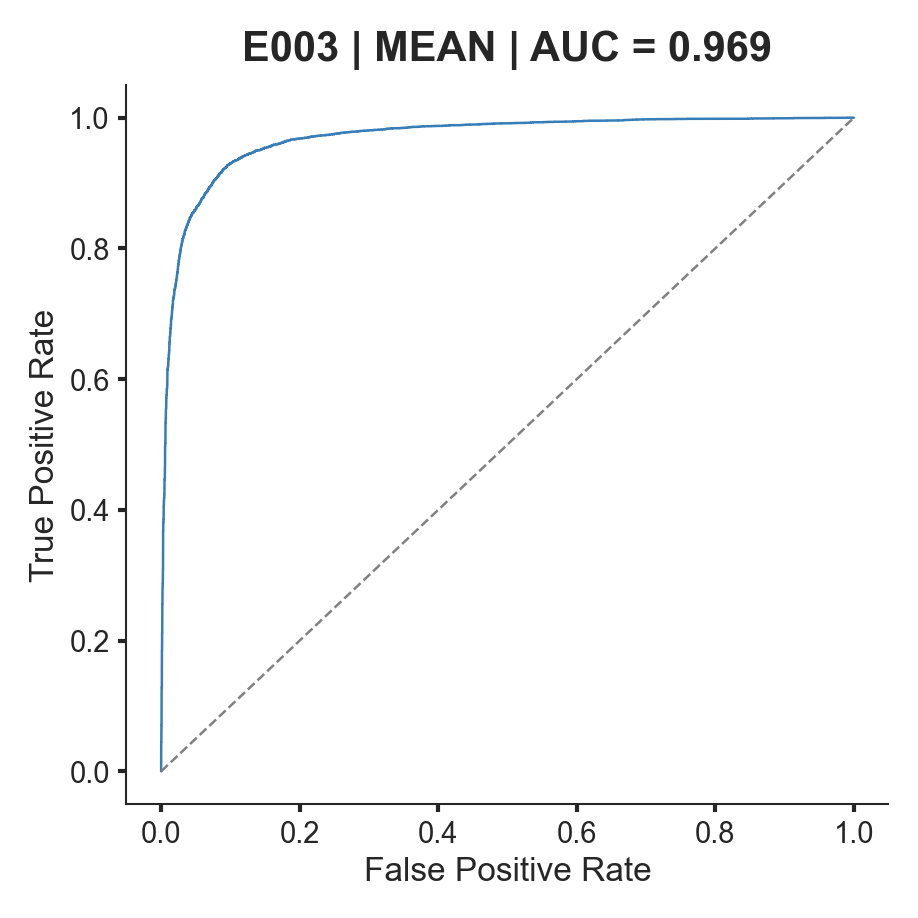

In [14]:
#
fpr, tpr, _ = metrics.roc_curve(data['mean_label_label'], data['mean_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['mean_label_label'],data['mean_label_pred'])

# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)

# 计算第二个模型的ROC曲线和F1分数
# 绘制两个模型的ROC曲线在一个图中
plt.plot(fpr, tpr, color='#377EB8', lw=0.6)
plt.plot([0, 1], [0, 1], lw=0.6, color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.text(x=0.85,y=0.05, s=f'AUC = {roc_auc:.3f}',fontdict={'size':6})

plt.title(f"{eid} | MEAN | AUC = {roc_auc:.3f}")
#plt.savefig("ROC.png")
plt.show()


# Cell type specific

In [15]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
with open('extra/datasets/results/cell_type_specific_mean_para.csv','w') as w:
    line = ['mean_auc','fold','eid']
    w.write('\t'.join(line) + '\n')
    for fold in [0,1,2,3]:
        for eid in eids:
            checkpoints = f'checkpoints/{eid}.{fold}.No_feature_bin.mean_para.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            cv_auc = ckpt['mean_label_val_auc']
            line = [str(cv_auc),str(fold), eid]
            w.write('\t'.join(line) + '\n')
        
        
cell_type_agnostic = pd.read_csv('extra/datasets/results/cell_type_agnostic_mean_para.csv',sep='\t')
cell_type_agnostic['cell_type'] = 'Agnostic model'
cell_type_specific = pd.read_csv('extra/datasets/benchmark/cell_type_specific_mean.csv',sep='\t')
cell_type_specific['cell_type'] = 'Specific model'
df = pd.concat([cell_type_specific,cell_type_agnostic], axis=0)
df = df[['mean_auc','fold','eid','cell_type']]
df.columns = ['auc','fold','eid','cell_type']
df['cell_type'] = 'mean_' + df['cell_type'] 


df


,auc,fold,eid,cell_type
0,97.009644,0,E003,mean_Specific model
1,95.302622,0,E118,mean_Specific model
2,98.448742,0,E116,mean_Specific model
3,96.946089,1,E003,mean_Specific model
4,96.267902,1,E118,mean_Specific model
5,98.781189,1,E116,mean_Specific model
6,97.095019,2,E003,mean_Specific model
7,96.473002,2,E118,mean_Specific model
8,98.900944,2,E116,mean_Specific model
9,97.076704,3,E003,mean_Specific model


### cell type specific Model Vs cell type agnostic Model

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_83969/3386309358.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


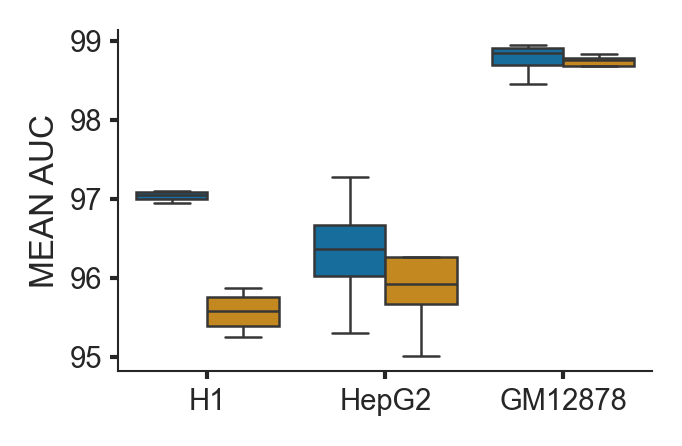

In [16]:
fig=plt.figure(figsize=(6/2.54,4/2.54) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
order = pd.Index(["E003","E118","E116"],name='marks')

ax = sns.boxplot(data=df, x='eid',y='auc',hue='cell_type',fliersize=0,linewidth=0.6,order=order)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the plot
plt.ylabel('MEAN AUC')
plt.xlabel('')
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax.legend().remove()
# Show the plot
plt.show()

# One-feature 

In [17]:
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
predictions = []
with open('extra/datasets/results/one_feature_indicators_mean_para.csv','w') as w:
    line = ['eid','keep_mark','fold','auc']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:
        for keep_mark in MARKS:
            remove_marks = deepcopy(MARKS)
            remove_marks.remove(keep_mark)
            
            for fold in [0,1,2,3]:
                checkpoints = f"checkpoints/{eid}.remove_{'_'.join(remove_marks)}.{fold}.No_feature_bin.mean_para.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                for target in targets:
                    auc = ckpt[f"{target}_val_auc"]
                    line = [eid,keep_mark,str(fold),str(auc)]
                    w.write(','.join(line) + '\n')

data = pd.read_csv('extra/datasets/results/one_feature_indicators_mean_para.csv')
data

,eid,keep_mark,fold,auc
0,E116,H3K4me1,0,94.359541
1,E116,H3K4me1,1,95.654967
2,E116,H3K4me1,2,96.095979
3,E116,H3K4me1,3,96.347800
4,E116,H3K4me3,0,97.103197
...,...,...,...,...
79,E003,H3K27ac,3,92.578109
80,E003,H3K9ac,0,93.859478
81,E003,H3K9ac,1,93.504948
82,E003,H3K9ac,2,94.390262


## MEAN one-feature ablation

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_83969/2386342946.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


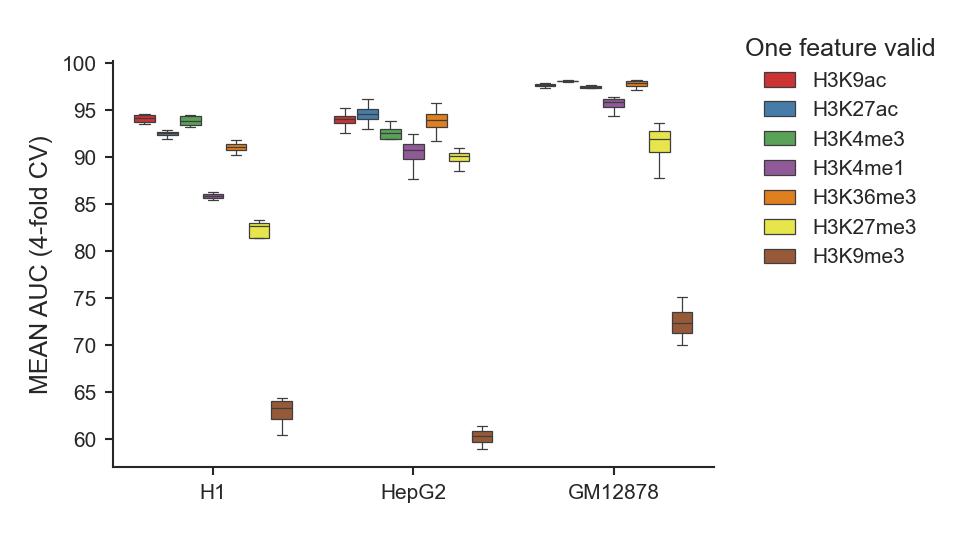

In [18]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'MEAN AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/datasets/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()

## Abelation Experiments

In [19]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]

with open('extra/datasets/results/ablation_mean_para.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write('\t'.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                checkpoints = f'checkpoints/{eid}.remove_{remove_mark}.{fold}.No_feature_bin.mean_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt['mean_label_val_auc']
                line = [str(auc),f"remove_{remove_mark}",str(fold), eid]
                w.write('\t'.join(line) + '\n')

            checkpoints = f'checkpoints/{eid}.{fold}.No_feature_bin.mean_para.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            auc = ckpt['mean_label_val_auc']
            line = [str(auc),'all_marks',str(fold),eid]
            w.write('\t'.join(line) + '\n')       

data =  pd.read_csv('extra/datasets/results/ablation_mean_para.csv',sep='\t')
data

### MEAN ablations

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_83969/2053686392.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=45)


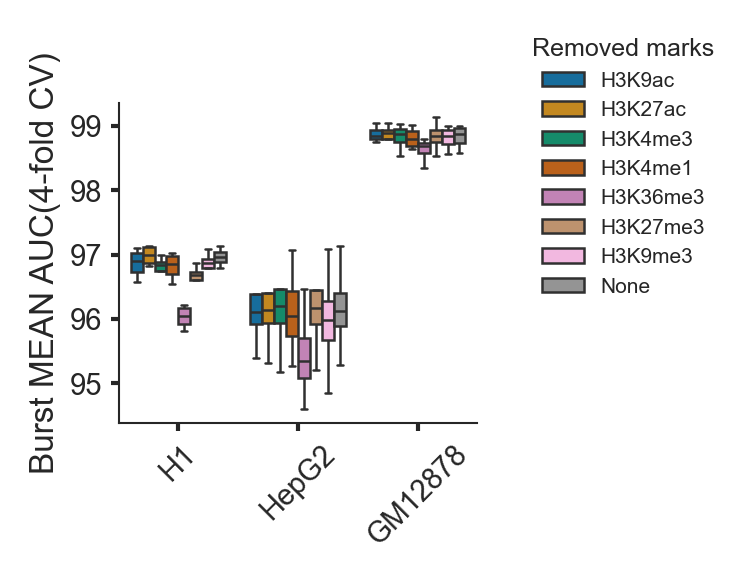

In [21]:
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(4/2.54, 4/2.54))

order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["remove_H3K9ac","remove_H3K27ac","remove_H3K4me3","remove_H3K4me1","remove_H3K36me3","remove_H3K27me3","remove_H3K9me3","all_marks"],name='marks')

sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax,order=order,hue_order=hue_order)
ax.legend().remove()  # Moves the legend outside the plot
ax.set_ylabel('Burst MEAN AUC(4-fold CV)')
ax.set_xlabel('')

handles, labels = ax.get_legend_handles_labels()
labels = ["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3","None"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.15) , title='Removed marks', fontsize=5,ncol=1,edgecolor='none',title_fontsize=6)

ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
plt.legend().remove()
# plt.savefig('extra/datasets/figures/Figure4_MEAN.eps', format='eps', bbox_inches='tight')

plt.show()

# Distance Importance

In [31]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
with open('extra/datasets/results/distance_mean_para.csv','w') as w:
    line = ['auc','fold','distance','eid']
    w.write('\t'.join(line) + '\n')
    for _eid in eids:
        for distance in [1000, 2000, 5000,10000,20000,40000]:
            for fold in [0,1,2,3]:

                checkpoints = f'checkpoints/{_eid}.{fold}.No_feature_bin.{distance}.mean_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                cv_auc = ckpt['mean_label_val_auc']
                line = [str(cv_auc),str(fold),str(distance), _eid]
                w.write('\t'.join(line) + '\n')
        

In [32]:
data = pd.read_csv('extra/datasets/results/distance_mean_para.csv',sep='\t')
data


,auc,fold,distance,eid
0,95.257831,0,1000,E003
1,94.905046,1,1000,E003
2,95.733123,2,1000,E003
3,95.425510,3,1000,E003
4,95.667662,0,2000,E003
...,...,...,...,...
67,98.950290,3,20000,E116
68,98.580768,0,40000,E116
69,98.788922,1,40000,E116
70,98.966780,2,40000,E116


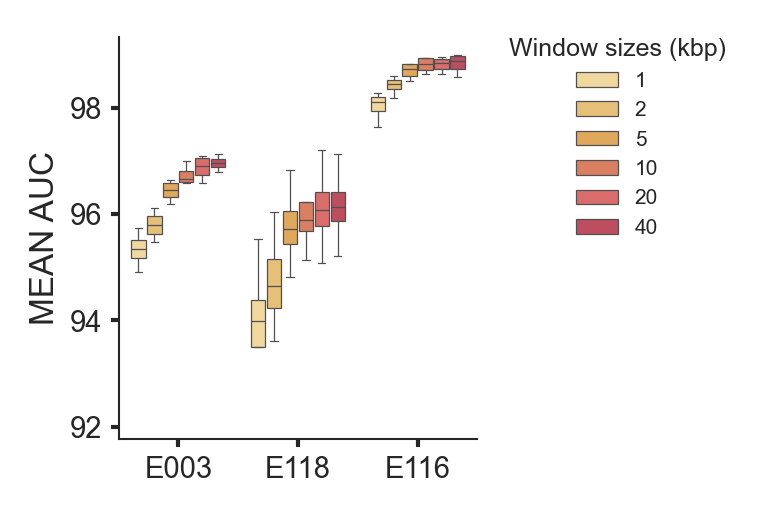

In [24]:
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(4/2.54, 4/2.54))


ax = sns.boxplot(data=data,x='eid',y='auc',hue='distance',fliersize=0,ax=ax,linewidth=0.3,order=order,
             gap=0.1,width=0.8,palette=[(253/255, 222/255, 145/255),(249/255, 196/255,101/255), (246/255, 172/255, 68/255),( 239/255, 116/255, 79/255), (237/255, 91/255,88/255), (207/255, 59/255, 82/255)],)


# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()
ax.set_xlabel('')
ax.set_ylabel('MEAN AUC')
handles, labels = ax.get_legend_handles_labels()
labels = ["1","2","5","10","20","40"]

fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.0, 1.01) , title='Window sizes (kbp)', fontsize=5,title_fontsize=6,ncol=1,edgecolor='none')

# plt.savefig('extra/datasets/figures/Figure2G.eps', format='eps', bbox_inches='tight')
plt.show()

# Feature importance

In [1]:
import torch
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
from captum.attr import DeepLift
from src.model.data import BurstFormerDataset
from src.model.net import  BurstFormer
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from matplotlib import rcParams, rcParamsDefault

from src.model.constants import get_config
from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)
# add_feature_bin = True
add_feature_bin = False

eid = 'E116'
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []


seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['mean_label']
npy_dir = "extra/datasets/processed/v1"

models = {}
datasets = {}
for fold in [0,1,2,3]:

    binsizes = [500]

    checkpoints = f"checkpoints/{eid}.{fold}.No_feature_bin.mean_para.model.pt"


    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

    #
    # Setup end.
    #

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]

    print(len(train_genes), len(val_genes))

    val_dataset = BurstFormerDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=config['num_works'])

    model = BurstFormer(
        n_feats_p,
        
        d_emb,
        d_head,
        
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
        
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models[fold] = DeepLift(model) 
    datasets[fold] = val_dataset


# 计算 DeepLIFT 归因（解释）值

data = pd.read_csv(f'extra/datasets/results/{eid}_predictions_mean_para.csv')
data = pd.merge(data,meta[['gene_id','chrom','start','strand']],how='inner',on='gene_id')
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target genes: 15487
n_feats_p:7
11738 3749
Target genes: 15487
n_feats_p:7
11298 4189
Target genes: 15487
n_feats_p:7
11674 3813
Target genes: 15487
n_feats_p:7
11751 3736


In [2]:
import scipy
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from typing import List, Union
import pandas as pd 
import numpy as np
from matplotlib.colors import Normalize, ListedColormap,LinearSegmentedColormap


def plot_heatmap(weight_matrix,axis=None,title=None, xlabel=None,ylabel="Locations",xticks = None,xticklabels=None,yticks=None,yticklabels=None,vmin=0,vmax=0.4):
    """
    Plots a clustered heatmap of the weights in a given subnetwork.

    Parameters:
    weight_matrix (DataFrame): A matrix containing the weights of edges in the subnetwork.
    output_path (str): The path where the output plot will be saved.

    Returns:
    None
    """
    
    # Define colors for the heatmap
    COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]


    g = sns.heatmap(weight_matrix, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=axis,vmin=vmin, vmax=vmax)
    if xticks:
        g.set_xticks(xticks)

    if yticks:
        g.set_yticks(yticks)


    # Set the font size and name for x-axis tick labels, and rotate them for better visibility
    # g.set_xticklabels(axis.get_xticklabels(), fontsize=6, rotation=50)

    # Set the font size and name for y-axis tick labels
    # g.set_yticklabels(axis.get_yticklabels(), rotation=360)

    # Customize tick parameters for the heatmap axes
    # g.tick_params(axis='both', which='major', length=0)

    # Adjust the colorbar tick parameters if collections exist
    if g.collections:
        g.collections[0].colorbar.ax.tick_params(labelsize=6, length=1)

    # Set labels for the x-axis and y-axis
    if xlabel:
        g.set_xlabel(xlabel)
    
    if ylabel:
        g.set_ylabel(ylabel)

    if xticklabels:
        g.set_xticklabels(xticklabels)

    if yticklabels:
        axis.set_yticklabels(yticklabels,rotation=360)

    g.set_title(title)


  0%|          | 0/3749 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3736/3736 [01:48<00:00, 34.38it/s]


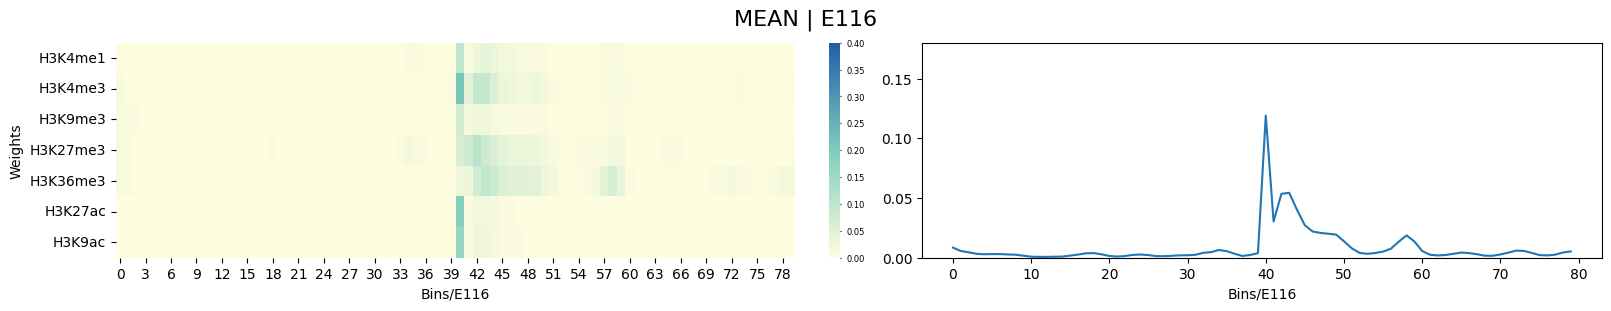

In [3]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/datasets/results/{eid}_mean_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/datasets/results/{eid}_mean_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"MEAN | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

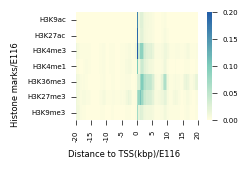

In [4]:
import matplotlib.colors as mcolors

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/datasets/results/{eid}_mean_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap(attributions1, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax, vmin=0, vmax=0.2)

ax.tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]

ax.set_xticks(np.arange(0, 81, 10), labels=xticklabels)
ax.set_yticklabels(yticks, rotation=360, fontsize=5)



cbar1 = ax.collections[0].colorbar

# 更改 colorbar 的字体大小
cbar1.ax.tick_params(width=0.5, labelsize=5)

fig.supxlabel(f"Distance to TSS(kbp)/{eid}", fontsize=6)
fig.supylabel(f"Histone marks/{eid}", fontsize=6)

plt.show()


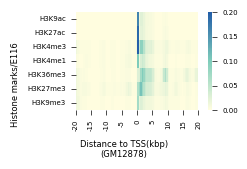

In [5]:
import matplotlib.colors as mcolors

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/datasets/results/{eid}_mean_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap(attributions1, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax, vmin=0, vmax=0.2)

ax.tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]

ax.set_xticks(np.arange(0, 81, 10), labels=xticklabels)
ax.set_yticklabels(yticks, rotation=360, fontsize=5)


cbar1 = ax.collections[0].colorbar

# 更改 colorbar 的字体大小
cbar1.ax.tick_params(width=0.5, labelsize=5)

fig.supxlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
fig.supylabel(f"Histone marks/{eid}", fontsize=6)

plt.show()


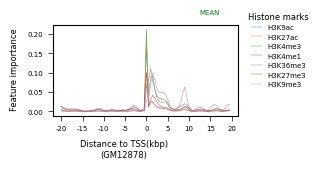

In [6]:
import matplotlib.colors as mcolors

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/datasets/results/{eid}_mean_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,linewidth=0.3)


xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax.set_xticks(np.arange(0, 81, 10), labels=xticklabels)
ax.tick_params(axis='both', labelsize=5, width=0.5)

fig.supxlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
fig.supylabel(f"Feature importance", fontsize=6,y=0.6)
ax.text(65,0.25,"MEAN",fontdict={"size":5,"color":"green"})
ax.legend().remove()
fig.legend(title="Histone marks",loc='upper left', bbox_to_anchor=(1, 1.0),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig(f'extra/datasets/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}_MEAN.eps', format='eps', bbox_inches='tight')

plt.show()


# Feature importance(Active)

In [2]:
import torch
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
from captum.attr import DeepLift
from src.model.data import BurstFormerDataset
from src.model.net import  BurstFormer
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from matplotlib import rcParams, rcParamsDefault

from src.model.constants import get_config
from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)
# add_feature_bin = True
add_feature_bin = False

eid = 'E116'
remove_marks = ['H3K9me3','H3K27me3','H3K36me3']
tag = '_'.join(remove_marks)

if remove_marks:
    config["remove_marks"] = remove_marks
else:
    config["remove_marks"] = []


seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['mean_label']
npy_dir = "extra/datasets/processed/v1"

models = {}
datasets = {}
for fold in [0,1,2,3]:

    binsizes = [500]

    checkpoints = f"checkpoints/{eid}.{tag}.{fold}.No_feature_bin.mean_para.model.pt"


    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

    #
    # Setup end.
    #

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]

    print(len(train_genes), len(val_genes))

    val_dataset = BurstFormerDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=config['num_works'])

    model = BurstFormer(
        n_feats_p,
        d_emb,
        d_head,
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models[fold] = DeepLift(model) 
    datasets[fold] = val_dataset


# 计算 DeepLIFT 归因（解释）值

data = pd.read_csv(f'extra/datasets/results/{eid}_predictions_mean_para.csv')
data = pd.merge(data,meta[['gene_id','chrom','start','strand']],how='inner',on='gene_id')
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


Target genes: 15487
n_feats_p:4
11738 3749
Target genes: 15487
n_feats_p:4
11298 4189
Target genes: 15487
n_feats_p:4
11674 3813
Target genes: 15487
n_feats_p:4
11751 3736


  0%|          | 0/3749 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3736/3736 [01:47<00:00, 34.68it/s]


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (7).

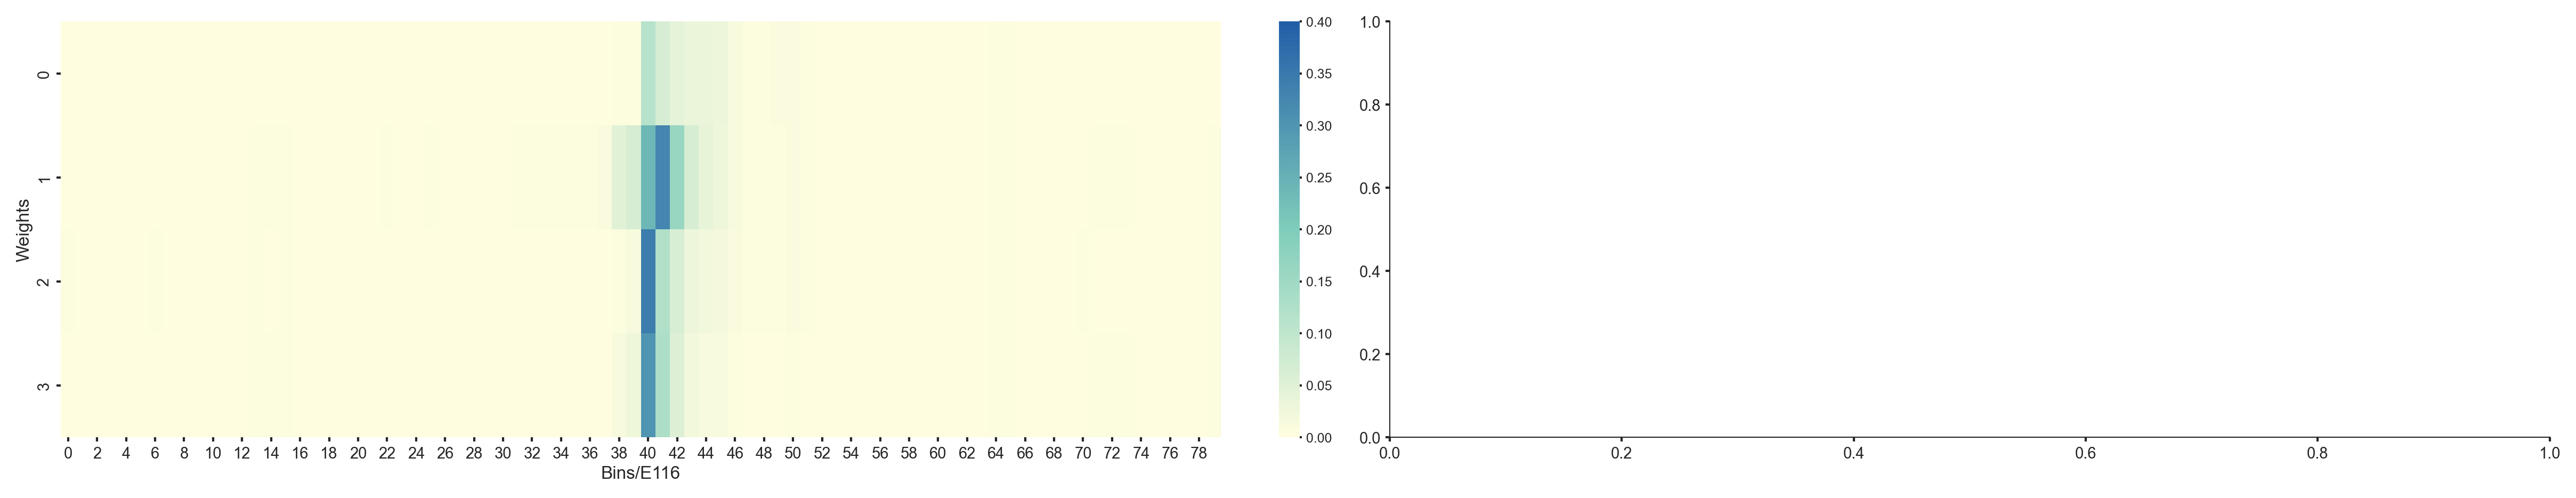

In [ ]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/datasets/results/{eid}_active_mean_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/datasets/results/{eid}_active_mean_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"MEAN | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

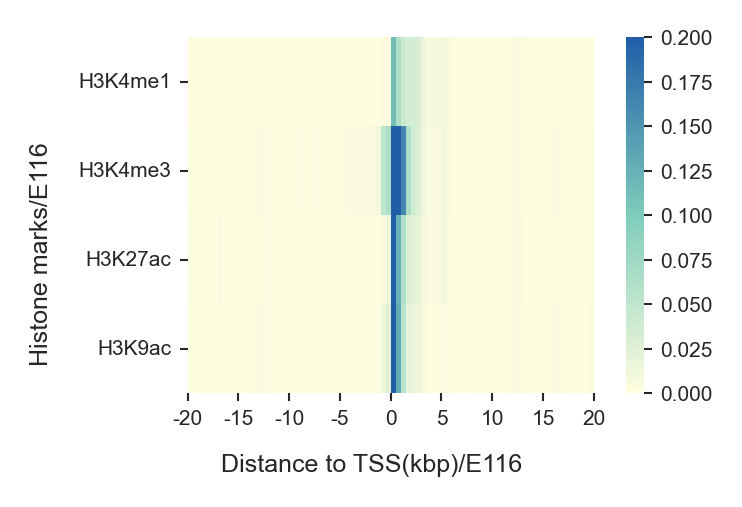

In [ ]:
import matplotlib.colors as mcolors

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
remove_marks = ['H3K9me3','H3K27me3','H3K36me3']
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [mark for _, mark in enumerate(MARKS) if mark not in remove_marks]
idxes = [yticks.index(mark) for mark in yticks]

with open(f'extra/datasets/results/{eid}_active_mean_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap(attributions1, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax, vmin=0, vmax=0.2)

ax.tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]

ax.set_xticks(np.arange(0, 81, 10), labels=xticklabels)
ax.set_yticklabels(yticks, rotation=360, fontsize=5)



cbar1 = ax.collections[0].colorbar

# 更改 colorbar 的字体大小
cbar1.ax.tick_params(width=0.5, labelsize=5)

fig.supxlabel(f"Distance to TSS(kbp)/{eid}", fontsize=6)
fig.supylabel(f"Histone marks/{eid}", fontsize=6)

plt.show()


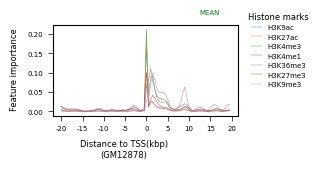

In [ ]:
import matplotlib.colors as mcolors

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/datasets/results/{eid}_mean_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,linewidth=0.3)


xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax.set_xticks(np.arange(0, 81, 10), labels=xticklabels)
ax.tick_params(axis='both', labelsize=5, width=0.5)

fig.supxlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
fig.supylabel(f"Feature importance", fontsize=6,y=0.6)
ax.text(65,0.25,"MEAN",fontdict={"size":5,"color":"green"})
ax.legend().remove()
fig.legend(title="Histone marks",loc='upper left', bbox_to_anchor=(1, 1.0),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig(f'extra/datasets/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}_MEAN.eps', format='eps', bbox_inches='tight')

plt.show()


# Feature importance(Repressive)

In [3]:
import torch
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
from captum.attr import DeepLift
from src.model.data import BurstFormerDataset
from src.model.net import  BurstFormer
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from matplotlib import rcParams, rcParamsDefault

from src.model.constants import get_config
from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)
# add_feature_bin = True
add_feature_bin = False

eid = 'E116'
remove_marks = ['H3K27ac','H3K9ac','H3K4me1','H3K4me3']
tag = '_'.join(remove_marks)

if remove_marks:
    config["remove_marks"] = remove_marks
else:
    config["remove_marks"] = []


seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['mean_label']
npy_dir = "extra/datasets/processed/v1"

models = {}
datasets = {}
for fold in [0,1,2,3]:

    binsizes = [500]

    checkpoints = f"checkpoints/{eid}.{tag}.{fold}.No_feature_bin.mean_para.model.pt"


    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

    #
    # Setup end.
    #

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]

    print(len(train_genes), len(val_genes))

    val_dataset = BurstFormerDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=config['num_works'])

    model = BurstFormer(
        n_feats_p,
        
        d_emb,
        d_head,
        
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
        
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models[fold] = DeepLift(model) 
    datasets[fold] = val_dataset


# 计算 DeepLIFT 归因（解释）值

data = pd.read_csv(f'extra/datasets/results/{eid}_predictions_mean_para.csv')
data = pd.merge(data,meta[['gene_id','chrom','start','strand']],how='inner',on='gene_id')
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


Target genes: 15487
n_feats_p:3
11738 3749
Target genes: 15487
n_feats_p:3
11298 4189
Target genes: 15487
n_feats_p:3
11674 3813
Target genes: 15487
n_feats_p:3
11751 3736


  0%|          | 0/3749 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3736/3736 [01:53<00:00, 32.99it/s]


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (7).

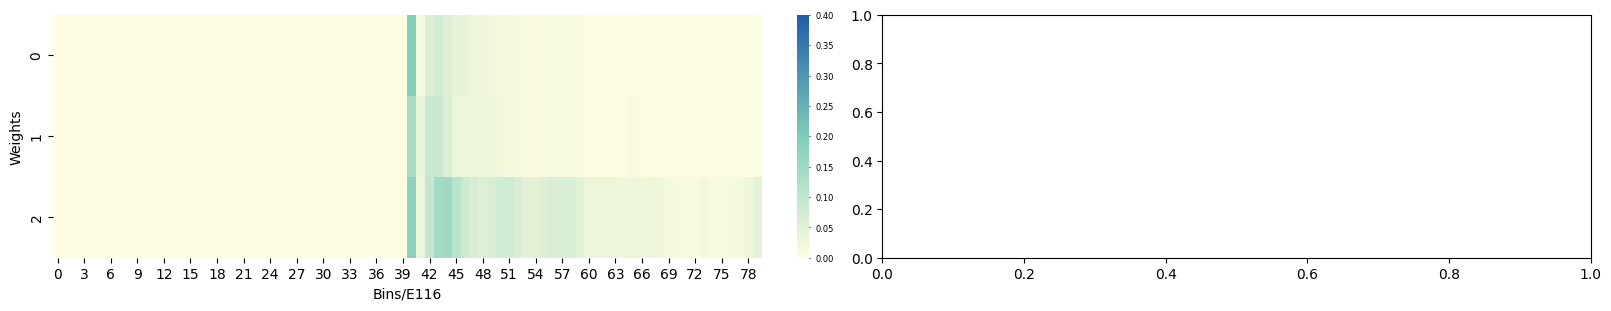

In [4]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/datasets/results/{eid}_repressive_mean_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/datasets/results/{eid}_repressive_mean_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"MEAN | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

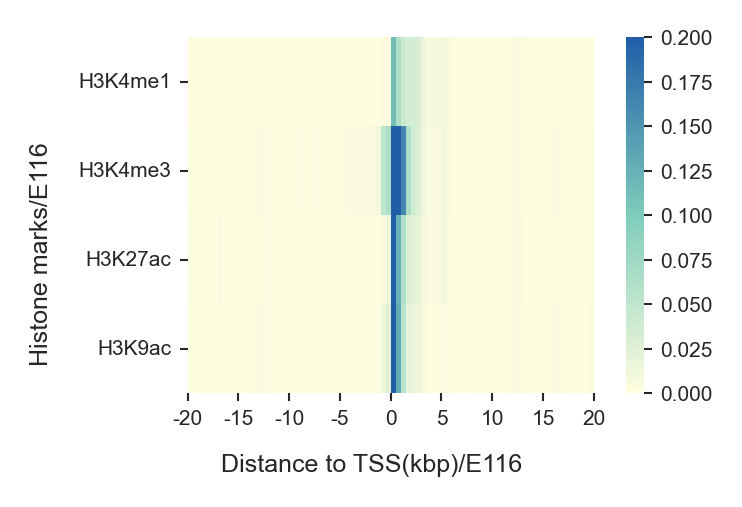

In [ ]:
import matplotlib.colors as mcolors



COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
remove_marks = ['H3K27ac','H3K9ac','H3K4me1','H3K4me3']
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [mark for _, mark in enumerate(MARKS) if mark not in remove_marks]
idxes = [yticks.index(mark) for mark in yticks]

with open(f'extra/datasets/results/{eid}_repressive_mean_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap(attributions1, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax, vmin=0, vmax=0.2)

ax.tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]

ax.set_xticks(np.arange(0, 81, 10), labels=xticklabels)
ax.set_yticklabels(yticks, rotation=360, fontsize=5)



cbar1 = ax.collections[0].colorbar

# 更改 colorbar 的字体大小
cbar1.ax.tick_params(width=0.5, labelsize=5)

fig.supxlabel(f"Distance to TSS(kbp)/{eid}", fontsize=6)
fig.supylabel(f"Histone marks/{eid}", fontsize=6)

plt.show()


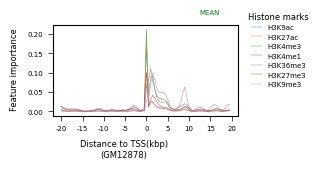

In [ ]:
import matplotlib.colors as mcolors

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/datasets/results/{eid}_mean_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,linewidth=0.3)


xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax.set_xticks(np.arange(0, 81, 10), labels=xticklabels)
ax.tick_params(axis='both', labelsize=5, width=0.5)

fig.supxlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
fig.supylabel(f"Feature importance", fontsize=6,y=0.6)
ax.text(65,0.25,"MEAN",fontdict={"size":5,"color":"green"})
ax.legend().remove()
fig.legend(title="Histone marks",loc='upper left', bbox_to_anchor=(1, 1.0),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig(f'extra/datasets/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}_MEAN.eps', format='eps', bbox_inches='tight')

plt.show()


# Active & Repressive marks valid

In [44]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
marks = ['H3K27ac H3K9ac H3K4me1 H3K4me3','H3K27ac H3K9ac H3K4me1 H3K4me3 H3K36me3','H3K9me3 H3K27me3 H3K36me3']
marks = ['H3K27ac H3K9ac H3K4me1 H3K4me3','H3K9me3 H3K27me3 H3K36me3']
target = 'mean'
with open(f'extra/datasets/results/active_repressive_{target}_para.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write(','.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                remove_mark = remove_mark.replace(' ','_')
                checkpoints = f'checkpoints/{eid}.{remove_mark}.{fold}.No_feature_bin.mean_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f'{target}_label_val_auc']
                line = [str(auc),f"{remove_mark}",str(fold), eid]
                w.write(','.join(line) + '\n')

            # checkpoints = f'checkpoints/{eid}.{fold}.No_feature_bin.mean_para.model.pt'
            # ckpt = torch.load(checkpoints,map_location=DEVICE)
            # auc = ckpt[f'{target}_label_val_auc']
            # line = [str(auc),'all_marks',str(fold),eid]
            # w.write(','.join(line) + '\n')       

data = pd.read_csv(f'extra/datasets/results/active_repressive_{target}_para.csv')

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_58261/525200441.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


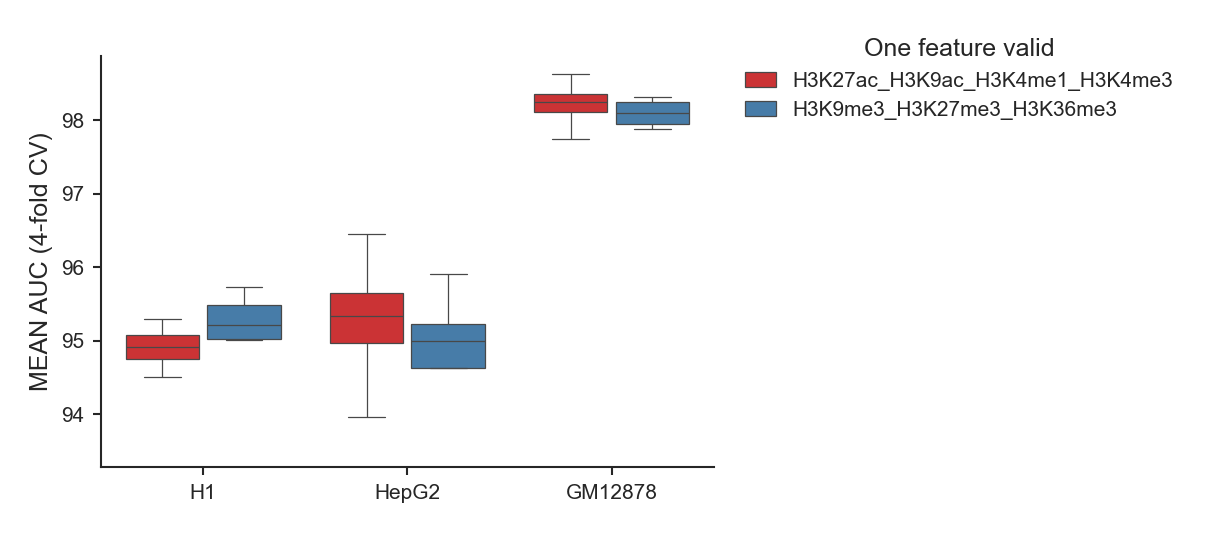

In [45]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))


# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3_H3K36me3','H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3'],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'MEAN AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/datasets/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()

In [38]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
marks = ['H3K27ac H3K9ac H3K4me1 H3K4me3','H3K27ac H3K9ac H3K4me1 H3K4me3 H3K36me3','H3K9me3 H3K27me3 H3K36me3']
marks = ['H3K27ac H3K9ac H3K4me1 H3K4me3','H3K9me3 H3K27me3 H3K36me3']
target = 'bs'
with open(f'extra/datasets/results/active_repressive_{target}_para.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write(','.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                remove_mark = remove_mark.replace(' ','_')
                checkpoints = f'checkpoints_temp/{eid}.{remove_mark}.{fold}.No_feature_bin.mean_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f'{target}_label_val_auc']
                line = [str(auc),f"{remove_mark}",str(fold), eid]
                w.write(','.join(line) + '\n')

            # checkpoints = f'checkpoints/{eid}.{fold}.No_feature_bin.mean_para.model.pt'
            # ckpt = torch.load(checkpoints,map_location=DEVICE)
            # auc = ckpt[f'{target}_label_val_auc']
            # line = [str(auc),'all_marks',str(fold),eid]
            # w.write(','.join(line) + '\n')       

data = pd.read_csv(f'extra/datasets/results/active_repressive_{target}_para.csv')

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_58261/4248707496.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


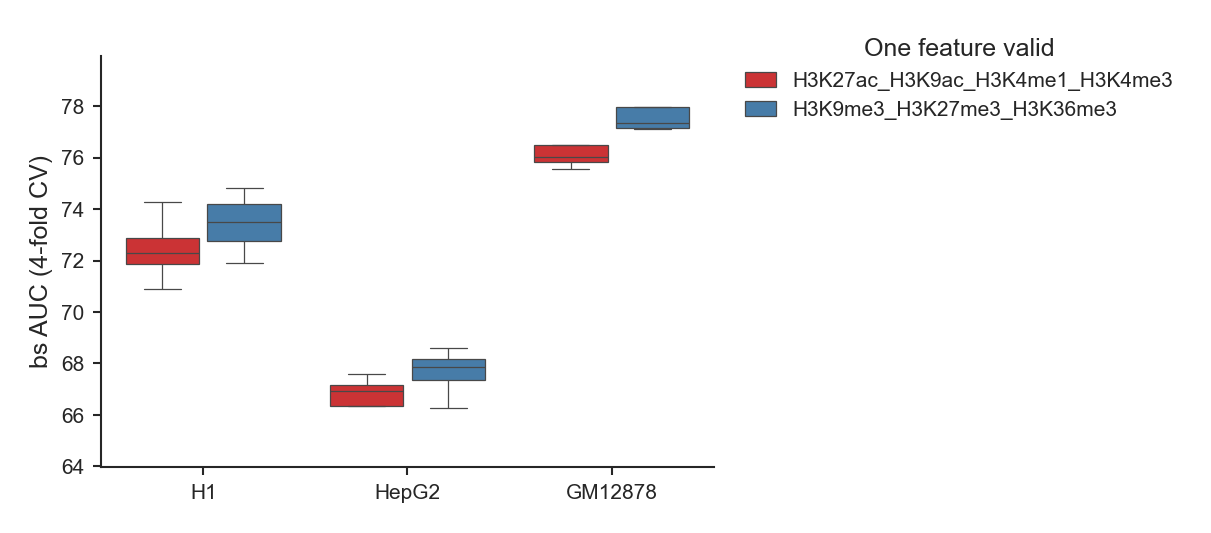

In [39]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))


# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3_H3K36me3','H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3'],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'{target} AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/datasets/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()

In [42]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
marks = ['H3K27ac H3K9ac H3K4me1 H3K4me3','H3K27ac H3K9ac H3K4me1 H3K4me3 H3K36me3','H3K9me3 H3K27me3 H3K36me3']
marks = ['H3K27ac H3K9ac H3K4me1 H3K4me3','H3K9me3 H3K27me3 H3K36me3']
target = 'bf'
with open(f'extra/datasets/results/active_repressive_{target}_para.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write(','.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                remove_mark = remove_mark.replace(' ','_')
                checkpoints = f'checkpoints_temp/{eid}.{remove_mark}.{fold}.No_feature_bin.mean_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f'{target}_label_val_auc']
                line = [str(auc),f"{remove_mark}",str(fold), eid]
                w.write(','.join(line) + '\n')

            # checkpoints = f'checkpoints/{eid}.{fold}.No_feature_bin.mean_para.model.pt'
            # ckpt = torch.load(checkpoints,map_location=DEVICE)
            # auc = ckpt[f'{target}_label_val_auc']
            # line = [str(auc),'all_marks',str(fold),eid]
            # w.write(','.join(line) + '\n')       

data = pd.read_csv(f'extra/datasets/results/active_repressive_{target}_para.csv')

KeyError: 'bf_label_val_auc'

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_58261/4248707496.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


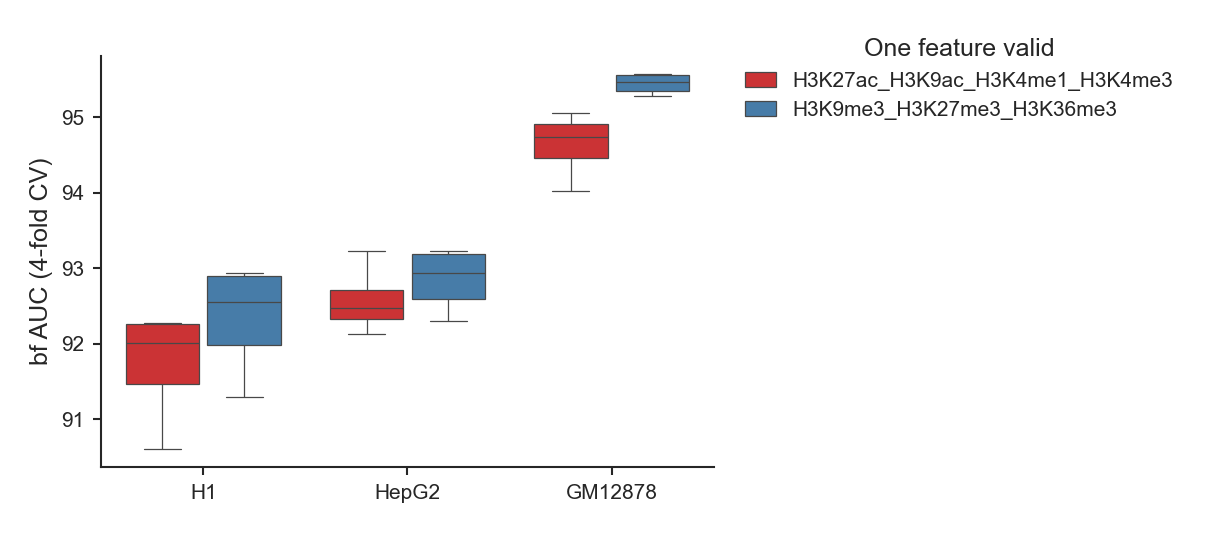

In [41]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))


# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3_H3K36me3','H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3'],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'{target} AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/datasets/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()